In [22]:
import matplotlib.pyplot as plt
from skimage import data
import numpy as np
from skimage.util import img_as_ubyte

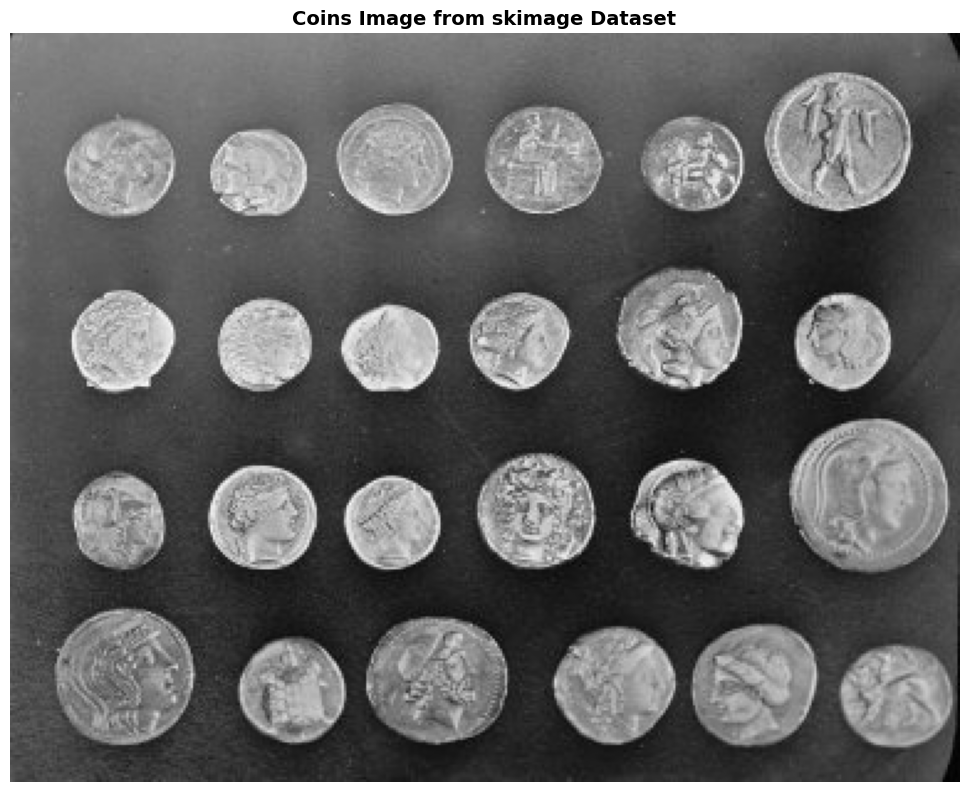

Coins image details
Image shape (height, width): (303, 384)
Total number of pixels: 116352
Data type: uint8

Pixel Grayscale Range:
 1- Minimum value: 1
 2- Maximum value: 252
 3- Mean value: 96.86
 4- Standard deviation: 52.88


In [23]:
# Task 1
#a) Load coins image
coins = data.coins()

# b) Visualize the image
plt.figure(figsize=(10, 8))
plt.imshow(coins, cmap='gray')
plt.title('Coins Image from skimage Dataset', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# c) Show image details

print("Coins image details")
print(f"Image shape (height, width): {coins.shape}")
print(f"Total number of pixels: {coins.size}")
print(f"Data type: {coins.dtype}")
print(f"\nPixel Grayscale Range:")
print(f" 1- Minimum value: {coins.min()}")
print(f" 2- Maximum value: {coins.max()}")
print(f" 3- Mean value: {coins.mean():.2f}")
print(f" 4- Standard deviation: {coins.std():.2f}")


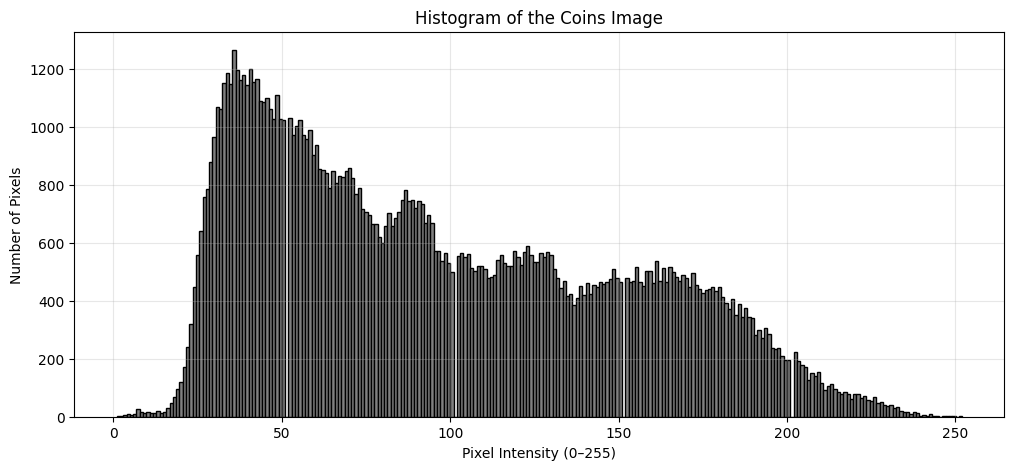

Histogram Analysis:
Dark peak (50-100): Coin edges and shadows
Middle peak (130-160): Coin surface
Bright peak (200-240): Background and highlights
The low-intensity peaks represent the dark coins, while the high-intensity peaks represent the bright background.


In [24]:
fig = plt.figure(figsize=(12, 5))
plt.hist(coins.flatten(), bins=256, color='gray', edgecolor='black')
plt.title('Histogram of the Coins Image')
plt.xlabel('Pixel Intensity (0–255)')
plt.ylabel('Number of Pixels')
plt.grid(True, alpha=0.3)
plt.show()

# Explaining the histogram
print("Histogram Analysis:")
print("Dark peak (50-100): Coin edges and shadows")
print("Middle peak (130-160): Coin surface")
print("Bright peak (200-240): Background and highlights")
print("The low-intensity peaks represent the dark coins, while the high-intensity peaks represent the bright background.")

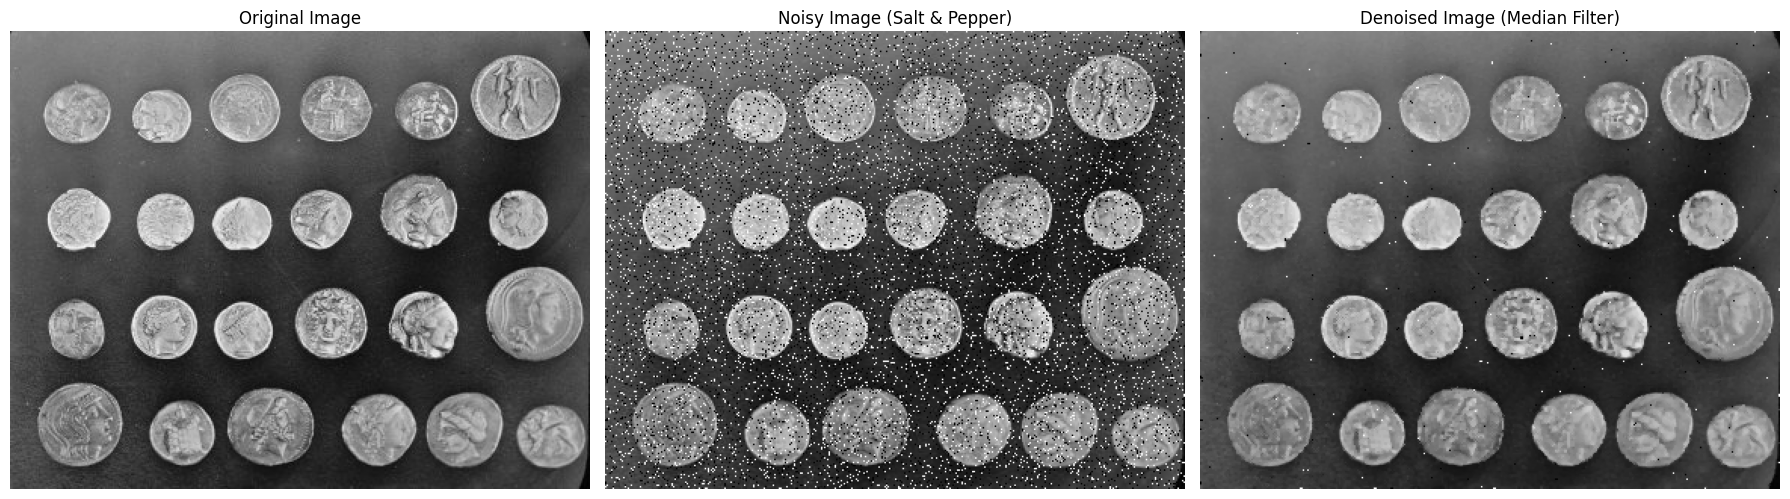

In [25]:
import matplotlib.pyplot as plt
from skimage import data, util
from skimage.filters import median
from skimage.morphology import disk

# Load and apply noise
original = data.coins()
noisy = util.random_noise(original, mode='s&p', amount=0.1)
denoised = median(noisy, disk(1))

# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title("Noisy Image (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(denoised, cmap='gray')
axes[2].set_title("Denoised Image (Median Filter)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

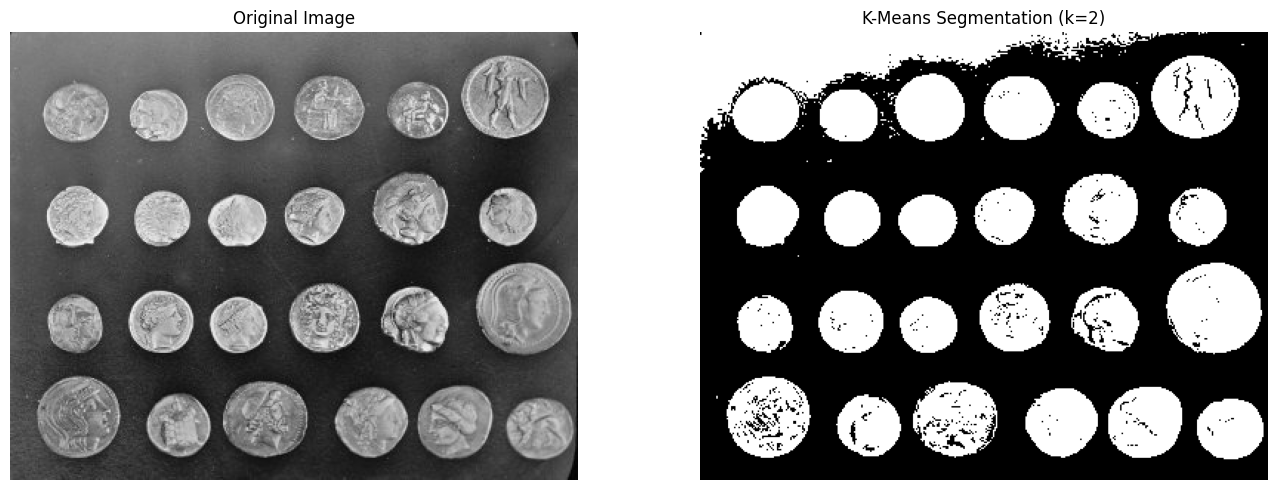

Cluster centers: [ 60.25473433 154.64430259]
Cluster 0 pixels: 71235
Cluster 1 pixels: 45117


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Reshape and apply K-means
flat_image = original.reshape((-1, 1))
kmeans = KMeans(n_clusters=2, random_state=0).fit(flat_image)
segmented = kmeans.labels_.reshape(original.shape)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(segmented, cmap='gray')
axes[1].set_title("K-Means Segmentation (k=2)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print clustering info
print(f"Cluster centers: {kmeans.cluster_centers_.flatten()}")
print(f"Cluster 0 pixels: {np.sum(segmented == 0)}")
print(f"Cluster 1 pixels: {np.sum(segmented == 1)}")

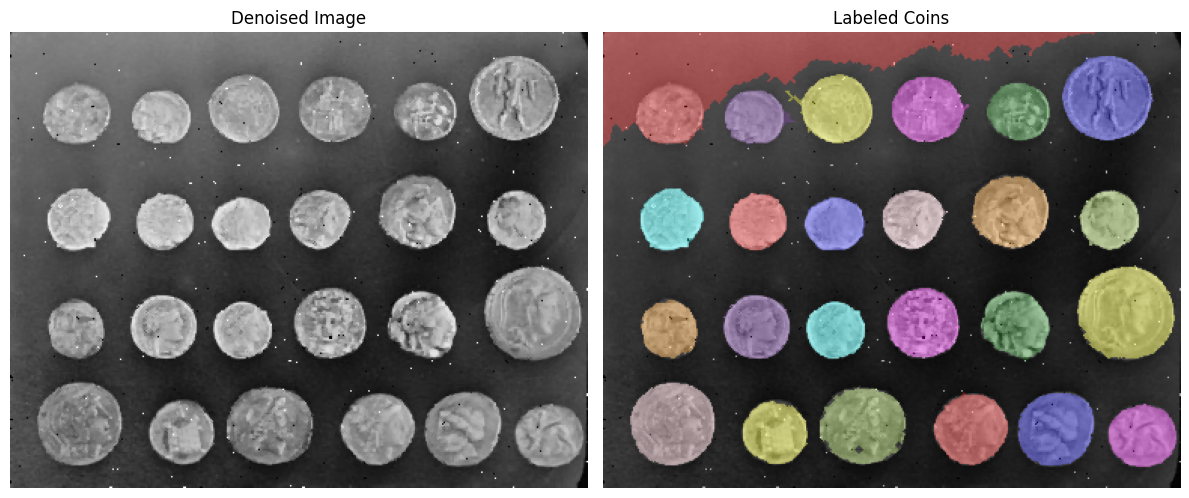

Number of coins detected: 24


In [27]:
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, closing, disk
from skimage.measure import label, regionprops
from skimage.color import label2rgb
import matplotlib.pyplot as plt

# Thresholding
thresh = threshold_otsu(denoised)
binary = denoised > thresh

# Morphological operations
cleaned = remove_small_objects(closing(binary, disk(2)), min_size=100)

# Labeling
labels = label(cleaned)
image_label_overlay = label2rgb(labels, image=denoised, bg_label=0)

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(denoised, cmap='gray')
axes[0].set_title('Denoised Image')
axes[0].axis('off')

axes[1].imshow(image_label_overlay)
axes[1].set_title('Labeled Coins')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Count coins
regions = regionprops(labels)
print(f"Number of coins detected: {len(regions)}")

Average Area: 1975.88
Average Major Axis Length: 58.30
Average Orientation: 0.05 rad


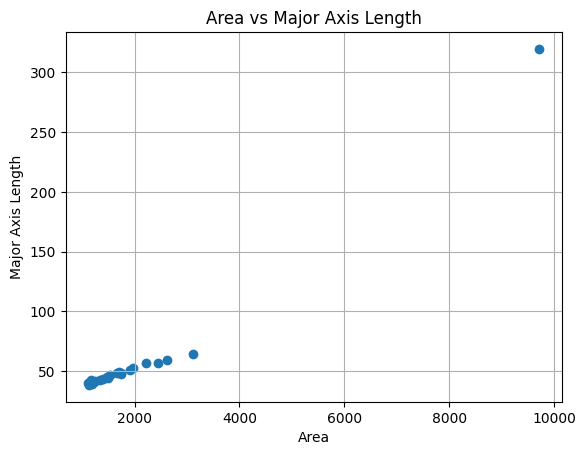

In [28]:
from skimage.measure import regionprops

regions = regionprops(labels)

areas = [r.area for r in regions]
majors = [r.major_axis_length for r in regions]
orientations = [r.orientation for r in regions]

print(f"Average Area: {np.mean(areas):.2f}")
print(f"Average Major Axis Length: {np.mean(majors):.2f}")
print(f"Average Orientation: {np.mean(orientations):.2f} rad")

plt.scatter(areas, majors)
plt.xlabel("Area")
plt.ylabel("Major Axis Length")
plt.title("Area vs Major Axis Length")
plt.grid(True)
plt.show()


In [29]:
big_regions = [r for r in regions if r.area > 1750]
num_big_coins = len(big_regions)
print(f"Number of coins with area > 1750: {num_big_coins}")


Number of coins with area > 1750: 7


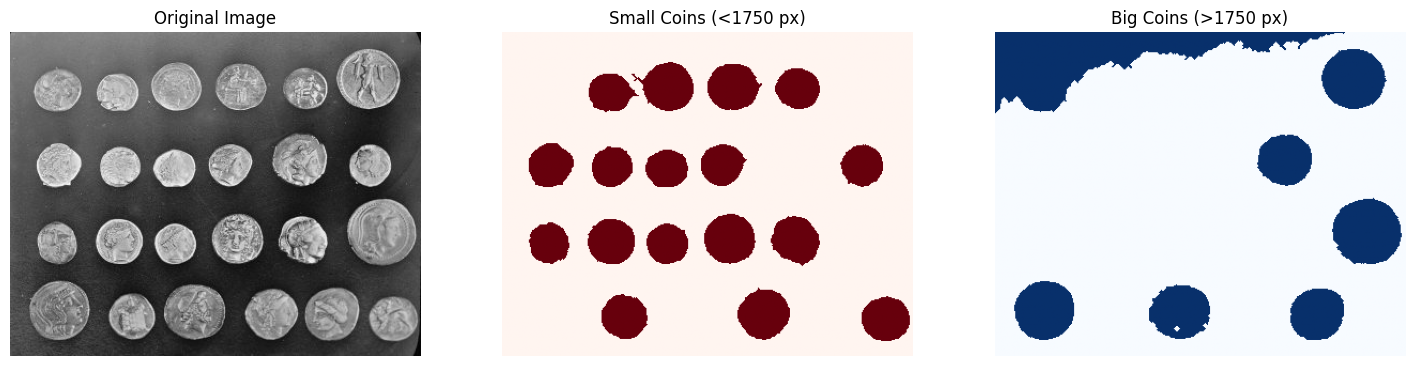

In [30]:
from skimage.color import label2rgb

small_mask = np.zeros_like(labels, dtype=bool)
big_mask = np.zeros_like(labels, dtype=bool)

for region in regions:
    if region.area > 1750:
        big_mask[labels == region.label] = True
    else:
        small_mask[labels == region.label] = True

overlay = np.zeros((*labels.shape, 3), dtype=np.uint8)
overlay[small_mask] = [255, 0, 0]
overlay[big_mask] = [0, 0, 255]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(original, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(small_mask, cmap='Reds')
ax[1].set_title("Small Coins (<1750 px)")
ax[1].axis('off')

ax[2].imshow(big_mask, cmap='Blues')
ax[2].set_title("Big Coins (>1750 px)")
ax[2].axis('off')
plt.show()

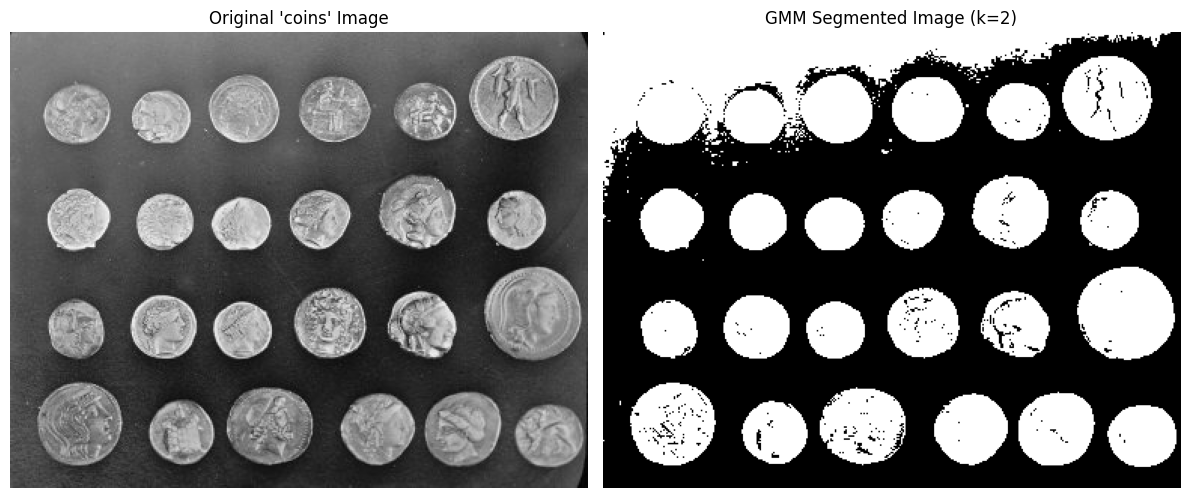

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.mixture import GaussianMixture

image = data.coins()

X = image.reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(X)
labels = gmm.predict(X)

segmented = labels.reshape(image.shape)

if np.mean(image[segmented == 0]) > np.mean(image[segmented == 1]):
    segmented = 1 - segmented


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original 'coins' Image")
ax[0].axis('off')

ax[1].imshow(segmented, cmap='gray')
ax[1].set_title("GMM Segmented Image (k=2)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [32]:
from skimage.feature import graycomatrix, graycoprops

glcm = graycomatrix(image, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')[0, 0]
dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]

print(f"Contrast: {contrast:.2f}")
print(f"Dissimilarity: {dissimilarity:.2f}")
print(f"Homogeneity: {homogeneity:.2f}")
print(f"Energy: {energy:.2f}")
print(f"Correlation: {correlation:.2f}")

Contrast: 1469.68
Dissimilarity: 20.30
Homogeneity: 0.13
Energy: 0.01
Correlation: 0.74
